## IMPORTING PYHTON LIBRARIES


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## LOAD DATASET

In [3]:
train=pd.read_csv("C:\\Users\\ROY\\Downloads\\Titanic-Dataset.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


## Perform EDA by using various maps(Heatmap,countplot,histogram,Boxplot)

<Axes: >

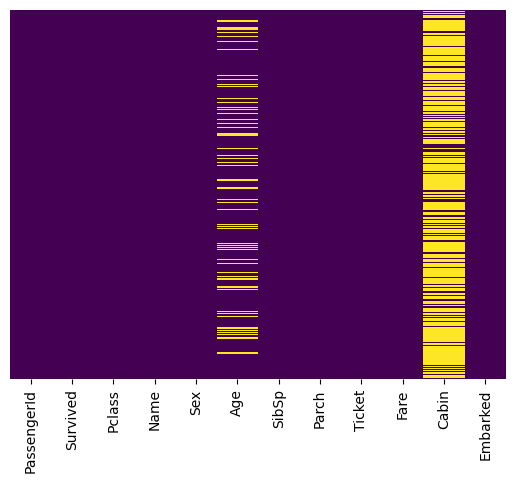

In [5]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

<Axes: xlabel='Survived', ylabel='count'>

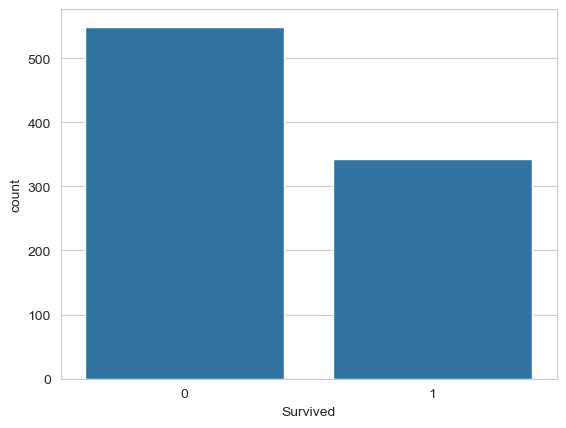

In [6]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',data=train)

<Axes: xlabel='Survived', ylabel='count'>

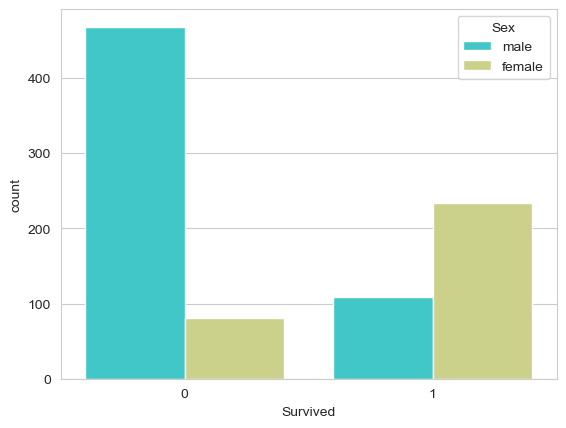

In [10]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',data=train,hue="Sex",palette="rainbow")

<Axes: xlabel='Survived', ylabel='count'>

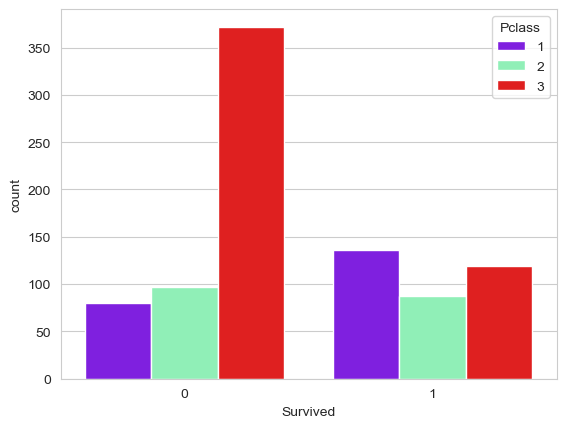

In [11]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Pclass',data=train,palette='rainbow')

<Axes: >

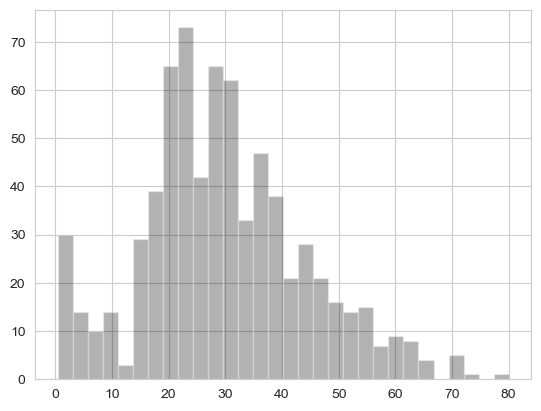

In [12]:
train['Age'].hist(bins=30,color='Black',alpha=0.3)

<Axes: xlabel='SibSp', ylabel='count'>

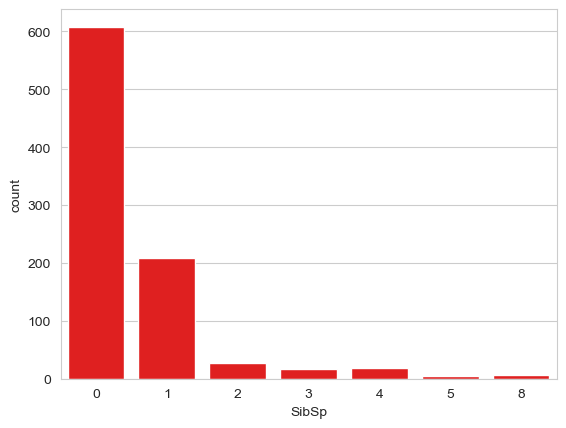

In [13]:
sns.set_style('whitegrid')
sns.countplot(x='SibSp',data=train,color="red")

<Axes: >

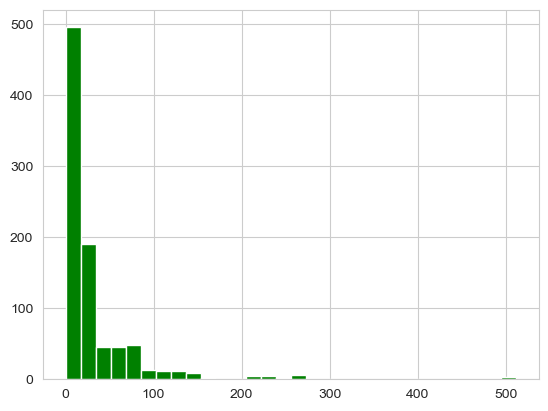

In [14]:
train['Fare'].hist(bins=30,color='green')

C:\Users\ROY\AppData\Local\Temp\ipykernel_11172\777481575.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass',y='Age',data=train,palette='rainbow')


<Axes: xlabel='Pclass', ylabel='Age'>

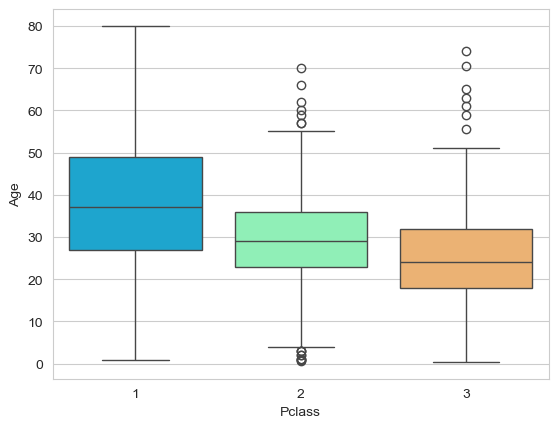

In [15]:
sns.boxplot(x='Pclass',y='Age',data=train,palette='rainbow')

## calculate Average of age to replace with null values

In [18]:
def aver(col):
    age=col[0]
    Pclass=col[1]
    if pd.isnull(age):
        if Pclass==1:
            return 37
        elif Pclass==2:
            return 28
        else:
            return 25
    else:
        return age
        
        

In [19]:
train['Age']=train[['Age','Pclass']].apply(aver,axis=1)

C:\Users\ROY\AppData\Local\Temp\ipykernel_11172\1980128919.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age=col[0]
C:\Users\ROY\AppData\Local\Temp\ipykernel_11172\1980128919.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass=col[1]


In [20]:
train['Age'].isnull().sum()

np.int64(0)

<Axes: >

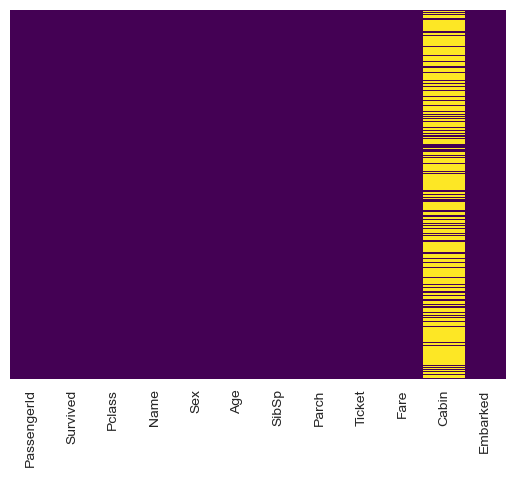

In [21]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [22]:
train.drop('Cabin',axis=1,inplace=True)

<Axes: >

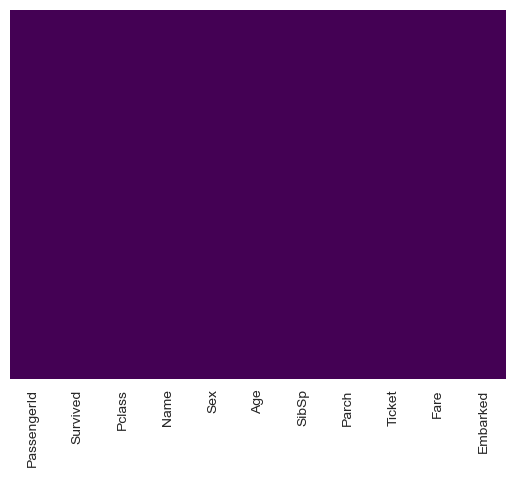

In [23]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

## Create Dummies for categorical values

In [25]:
sex=pd.get_dummies(train['Sex'],drop_first=True)
embarck=pd.get_dummies(train['Embarked'],drop_first=True)

In [26]:
train.drop(['Sex','Embarked','Ticket','Name'],axis=1,inplace=True)

In [27]:
train=pd.concat([train,sex,embarck],axis=1)

## Train the data set

In [28]:
x=train.drop(['Survived'],axis=1)

In [29]:
y=train['Survived']

In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=101)


In [31]:
print(y.value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
regression=LogisticRegression()
regression.fit(x_train,y_train)
prediction=regression.predict(x_test)
print("Accuracy:",accuracy_score(y_test,prediction))


Accuracy: 0.7686567164179104


C:\Users\ROY\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
cm = confusion_matrix(y_test, prediction)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[134  20]
 [ 42  72]]


In [38]:
print("\nClassification Report:")
print(classification_report(y_test, prediction))


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       154
           1       0.78      0.63      0.70       114

    accuracy                           0.77       268
   macro avg       0.77      0.75      0.76       268
weighted avg       0.77      0.77      0.76       268

